# Análisis de la Base de Datos

### Ruta del Dataset

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configuración de la ruta relativa al dataset (cargar previamente, no está en el repo)
DATASET_PATH = "../datasets"

### Histograma medio del dataset en escala de grises

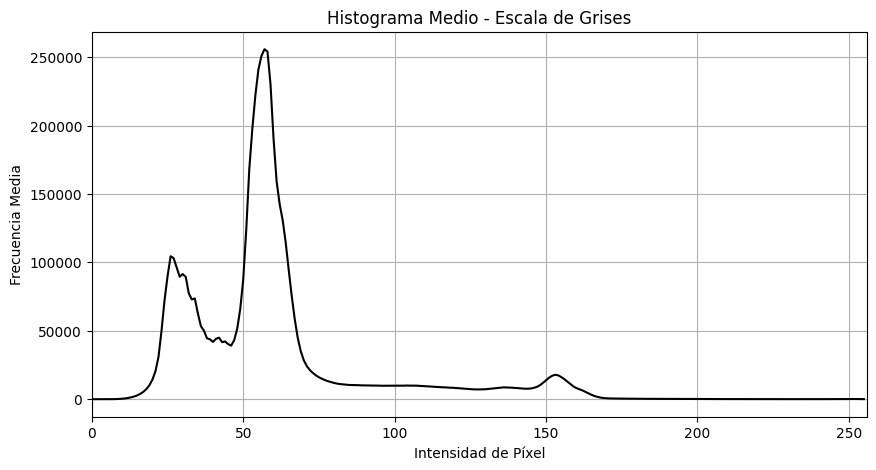

In [17]:
def calculate_average_grayscale_histogram(dataset_path: str) -> None:
    """
    Calcula y grafica el histograma medio en escala de grises de un conjunto de imágenes.

    Args:
        dataset_path (str): Ruta al directorio que contiene las imágenes JPG.
    """
    path = Path(dataset_path)
    image_files = list(path.glob("*.jpg"))
    
    if not image_files:
        print("Error: No se encontraron imágenes en la ruta especificada.")
        return

    # Inicialización del acumulador para 256 niveles de gris
    total_hist = np.zeros((256, 1))
    
    for file in image_files:
        img = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            hist = cv2.calcHist([img], [0], None, [256], [0, 256])
            total_hist += hist

    # Cálculo de la media
    avg_hist = total_hist / len(image_files)

    plt.figure(figsize=(10, 5))
    plt.title("Histograma Medio - Escala de Grises")
    plt.xlabel("Intensidad de Píxel")
    plt.ylabel("Frecuencia Media")
    plt.plot(avg_hist, color='black')
    plt.xlim([0, 256])
    plt.grid(True)
    plt.show()

calculate_average_grayscale_histogram(DATASET_PATH)

### Histograma medio del dataset en espacio de color HSV

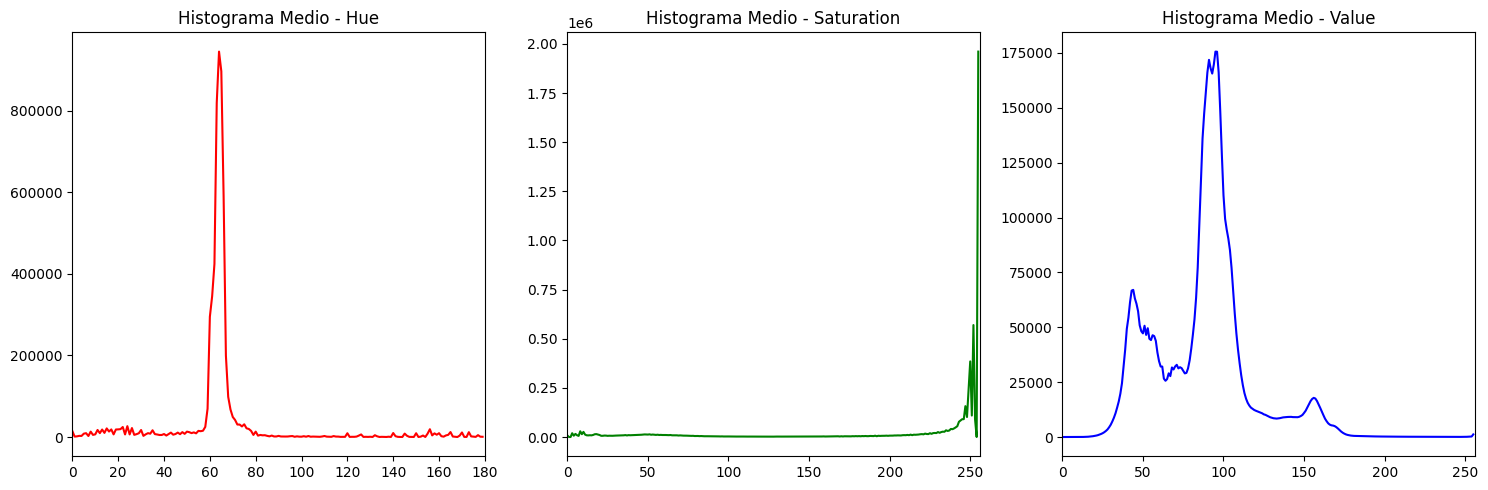

In [18]:
def calculate_average_hsv_histogram(dataset_path: str) -> None:
    """
    Calcula y grafica el histograma medio de los canales Hue, Saturation y Value de un conjunto de imágenes.

    Args:
        dataset_path (str): Ruta al directorio que contiene las imágenes JPG.
    """
    path = Path(dataset_path)
    image_files = list(path.glob("*.jpg"))
    
    if not image_files:
        return

    # Acumuladores independientes para cada canal
    total_hist_h = np.zeros((180, 1))
    total_hist_s = np.zeros((256, 1))
    total_hist_v = np.zeros((256, 1))
    valid_images = 0
    
    for file in image_files:
        img = cv2.imread(str(file))
        if img is not None:
            hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            
            hist_h = cv2.calcHist([hsv_img], [0], None, [180], [0, 180])
            hist_s = cv2.calcHist([hsv_img], [1], None, [256], [0, 256])
            hist_v = cv2.calcHist([hsv_img], [2], None, [256], [0, 256])
            
            total_hist_h += hist_h
            total_hist_s += hist_s
            total_hist_v += hist_v
            valid_images += 1

    if valid_images == 0:
        return

    avg_hist_h = total_hist_h / valid_images
    avg_hist_s = total_hist_s / valid_images
    avg_hist_v = total_hist_v / valid_images

    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title("Histograma Medio - Hue")
    plt.plot(avg_hist_h, color='r')
    plt.xlim([0, 180])
    
    plt.subplot(1, 3, 2)
    plt.title("Histograma Medio - Saturation")
    plt.plot(avg_hist_s, color='g')
    plt.xlim([0, 256])
    
    plt.subplot(1, 3, 3)
    plt.title("Histograma Medio - Value")
    plt.plot(avg_hist_v, color='b')
    plt.xlim([0, 256])
    
    plt.tight_layout()
    plt.show()

calculate_average_hsv_histogram(DATASET_PATH)

### Reducción de ruido y detección de bordes (Canny)

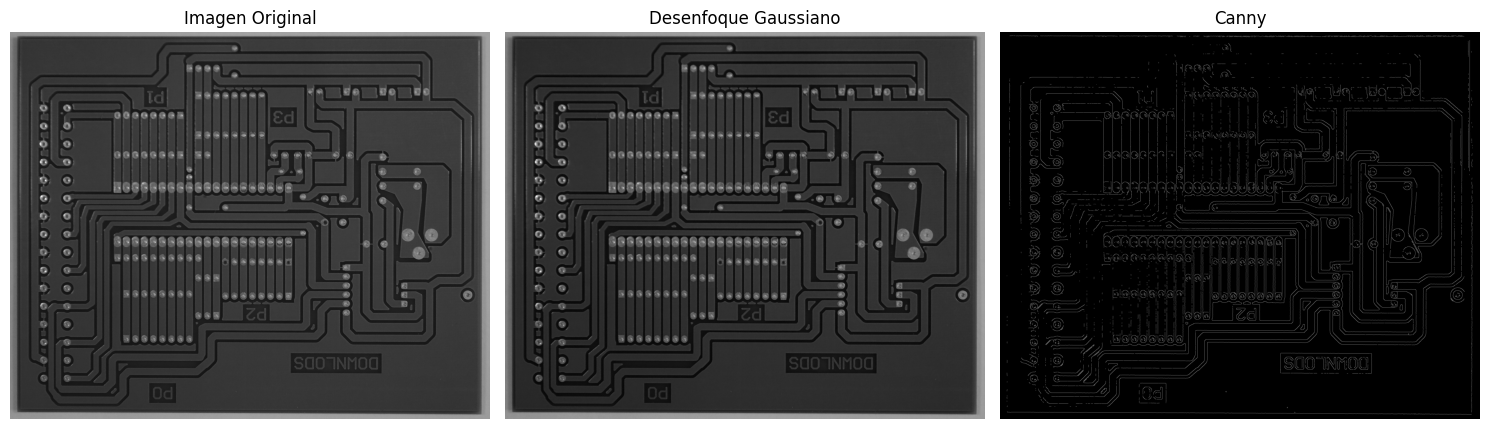

In [19]:
def apply_blur_and_canny(image_path: str, kernel_size: tuple = (5, 5), threshold1: int = 80, threshold2: int = 100) -> None:
    """
    Aplica un filtro de desenfoque gaussiano para reducir ruido y posteriormente el detector de bordes Canny.

    Args:
        image_path (str): Ruta a una imagen de prueba.
        kernel_size (tuple): Tamaño de la matriz para el filtro gaussiano.
        threshold1 (int): Límite inferior para la histéresis de Canny.
        threshold2 (int): Límite superior para la histéresis de Canny.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Error al cargar la imagen.")
        return

    # Reducción de ruido de alta frecuencia
    blurred_img = cv2.GaussianBlur(img, kernel_size, 0)
    
    # Detección de gradientes
    edges = cv2.Canny(blurred_img, threshold1, threshold2)

    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title("Imagen Original")
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title("Desenfoque Gaussiano")
    plt.imshow(blurred_img, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title("Canny")
    plt.imshow(edges, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Extrae la primera imagen válida para demostración
try:
    sample_image_path = str(list(Path(DATASET_PATH).glob("*.jpg"))[0])
    apply_blur_and_canny(sample_image_path)
except IndexError:
    print("No hay imágenes disponibles para la demostración.")

# Transformada de Hough

Análisis completado: Se detectaron 105 círculos.


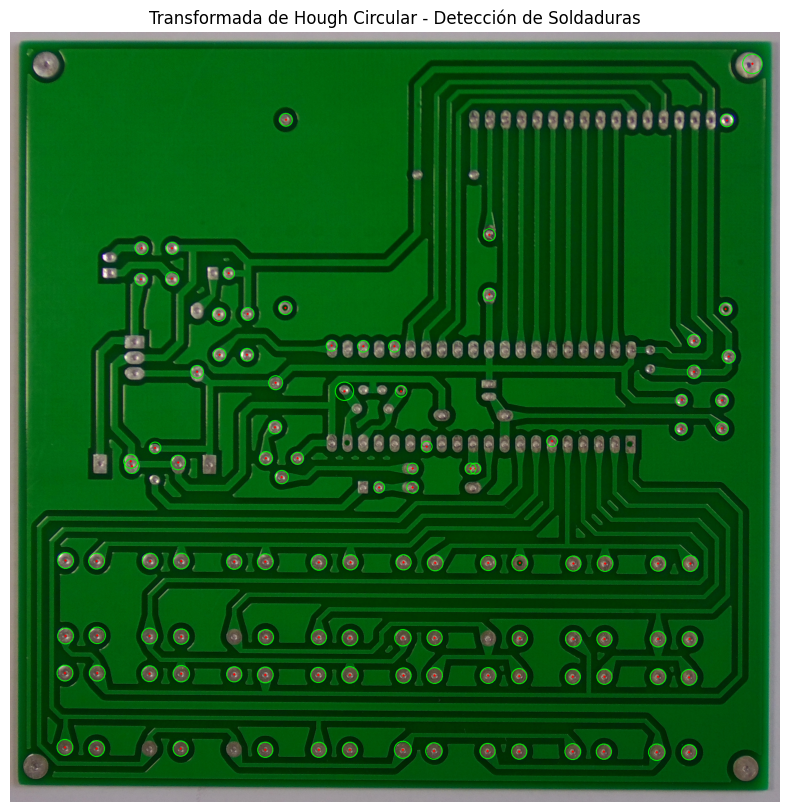

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_circular_hough_transform(
    image_path: str = "../datasets/Muestra_006.jpg", 
    min_dist: int = 15, 
    param1: int = 100, 
    param2: int = 23, 
    min_radius: int = 18, 
    max_radius: int = 35
) -> None:
    """
    Detecta y visualiza círculos en una imagen utilizando la Transformada de Hough Circular.
    
    Se han optimizado los parámetros por defecto para la detección de puntos 
    de soldadura en placas de circuito impreso.

    Args:
        image_path (str): Ruta de la imagen objetivo.
        min_dist (int): Distancia mínima entre los centros de los círculos detectados.
        param1 (int): Umbral superior para el detector de bordes interno (Canny).
        param2 (int): Umbral de acumulación para los centros. Valores más bajos detectan más círculos.
        min_radius (int): Radio mínimo esperado de los elementos a detectar.
        max_radius (int): Radio máximo esperado de los elementos a detectar.
    """
    img_color = cv2.imread(image_path)
    
    # Control de error de ruta
    if img_color is None:
        print(f"Error: No se pudo cargar la imagen '{image_path}'. Verifique la ruta y el nombre del archivo.")
        return
        
    img_display = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    
    # Filtro de mediana para suavizar el ruido interno preservando los bordes
    img_blur = cv2.medianBlur(img_gray, 13)
    
    circles = cv2.HoughCircles(
        img_blur, 
        cv2.HOUGH_GRADIENT, 
        dp=1, 
        minDist=min_dist,
        param1=param1,
        param2=param2,
        minRadius=min_radius,
        maxRadius=max_radius
    )

    if circles is not None:
        circles = np.uint16(np.around(circles))
        print(f"Análisis completado: Se detectaron {circles.shape[1]} círculos.")
        
        for i in circles[0, :]:
            # Trazo de la circunferencia delimitadora
            cv2.circle(img_display, (i[0], i[1]), i[2], (0, 255, 0), 2)
            # Trazo del centro geométrico
            cv2.circle(img_display, (i[0], i[1]), 2, (255, 0, 0), 3)
    else:
        print("Análisis completado: No se detectaron círculos. Considere reducir 'param2' o ajustar los radios.")

    plt.figure(figsize=(10, 10))
    plt.title("Transformada de Hough Circular - Detección de Soldaduras")
    plt.imshow(img_display)
    plt.axis('off')
    plt.show()

# Ejecución directa sin depender de variables locales de otras celdas
apply_circular_hough_transform()